In [1]:
import numpy as np
import tables
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from IPython.display import Audio, display, clear_output
import ipywidgets as widgets

h5 = tables.open_file(
    r"Y:\danielmk\okeon\dataset.h5",
    mode="r+"
)

group = h5.root.train
samples_tbl = group.samples
audio_arr = group.audio
quality_arr = group.quality_rating

def get_random_unrated_index():
    qualities = quality_arr[:]          # 1D numpy array
    unrated = np.isnan(qualities)

    if not np.any(unrated):
        raise RuntimeError("All samples are already rated!")

    indices = np.where(unrated)[0]
    return np.random.choice(indices)


def show_sample(idx):
    audio = audio_arr[idx]
    meta = samples_tbl[idx]

    sr = meta["sr"]

    display(Audio(audio, rate=sr, autoplay=True))

    fig, axes = plt.subplots(2, 1, figsize=(10, 6))

    # ---- waveform ----
    t = np.arange(len(audio)) / sr
    axes[0].plot(t, audio, linewidth=0.5)
    axes[0].set_title(
        f"Waveform | species={meta['species'].decode()} | file={meta['filename'].decode()}"
    )
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_xlim((0, 2.5))

    # ---- spectrogram ----
    f, tt, Sxx = spectrogram(audio, fs=sr, nperseg=1024, noverlap=768)
    axes[1].pcolormesh(tt, f, 10 * np.log10(Sxx + 1e-12), shading="auto")
    axes[1].set_ylabel("Frequency (Hz)")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_title("Spectrogram")
    axes[1].set_xlim((0, 2.5))

    plt.tight_layout()
    plt.show()

    

quality_slider = widgets.FloatSlider(
    value=0.0,
    min=0.0,
    max=3.0,
    step=1.0,
    description="Quality",
    continuous_update=False,
)

save_button = widgets.Button(description="Save rating")
next_button = widgets.Button(description="Next sample")

status = widgets.Label()

output = widgets.Output()

current_idx = None


def load_next_sample(b):
    global current_idx
    status.value = f"Sample index: {current_idx} (random)"
    try:
        current_idx = get_random_unrated_index()

        rating = quality_arr[current_idx]
        quality_slider.value = 0.0 if np.isnan(rating) else float(rating)
        status.value = f"Sample index: {current_idx}"

        # ✅ only clear/redraw THIS area
        with output:
            output.clear_output(wait=True)
            show_sample(current_idx)

    except Exception as e:
        status.value = f"ERROR: {e}"


def on_save_clicked(b):

    quality_arr[current_idx] = quality_slider.value
    quality_arr.flush()

    status.value = (
        f"Saved rating {quality_slider.value} "
        f"for sample {current_idx}"
    )
    
save_button.on_click(on_save_clicked)
next_button.on_click(load_next_sample)

ui = widgets.VBox([
    widgets.HBox([quality_slider]),
    widgets.HBox([save_button, next_button]),
    status,
    output,
])

display(ui)


In [2]:

clear_output(wait=True)
print("Output cleared")


Output cleared


In [ ]:
(~np.isnan(h5.root.train.quality_rating)).sum()

np.int64(599)

In [3]:
np.unique(h5.root.train.quality_rating, return_counts=True)

(array([ 0.,  1.,  2.,  3., nan], dtype=float32),
 array([ 1649,  2459,  1000,   275, 21934]))

NameError: name 'librosa' is not defined

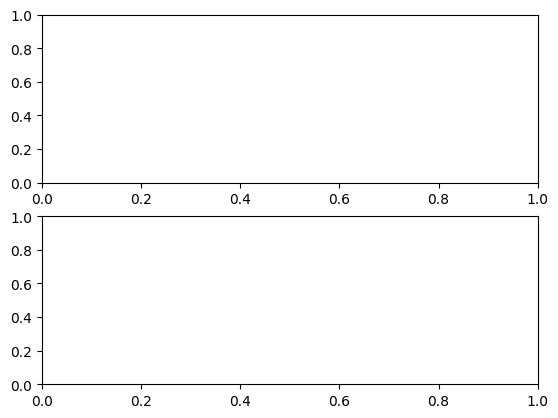

In [6]:
fig, ax = plt.subplots(2, 1)
img = librosa.display.specshow(D, y_axis='linear', x_axis='s', sr=sr, ax=ax[0])
t = np.arange(0, env_smooth.shape[0] * (1/sr), 1/sr)
ax[1].plot(t, env_smooth)

In [3]:
h5.close()

In [30]:
test_audio = h5.root.train.audio[np.argwhere(h5.root.train.quality_rating.read() == 1)[:, 0][2]]

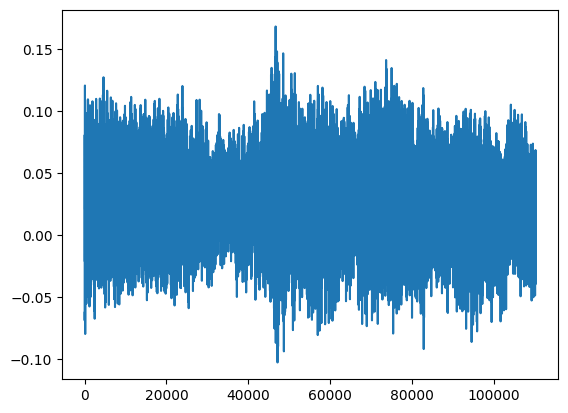

In [31]:
plt.plot(test_audio)

In [14]:
h5.root.train.quality_rating.read()==4

array([False, False, False, ..., False, False, False], shape=(27317,))

In [11]:
np.argwhere(h5.root.train.quality_rating.read() == 3)[:, 0]

array([  917,  1001,  1023,  1348,  1698,  1719,  1804,  1944,  1956,
        2006,  3044,  3781,  3896,  4338,  4709,  4958,  4978,  5029,
        5478,  5479,  6992,  7399,  8286,  8683,  9048,  9587, 11624,
       11709, 11812, 11824, 11834, 12148, 12371, 12709, 12735, 12775,
       12819, 12844, 13183, 13431, 13720, 13724, 14119, 16034, 16346,
       16539, 16671, 16988, 17161, 17245, 17421, 20378, 20409, 20735,
       22452, 22497, 23141, 23621, 24315, 25026, 25546, 25660, 25850,
       26605, 27047])

In [5]:
h5.root.train.quality_rating.read()

array([nan, nan, nan, ..., nan, nan, nan], shape=(27317,), dtype=float32)